In [1]:
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read Elnaz hydro
elnaz_niag_files = glob('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/hydrodata_elnaz_2030/RMN_*.csv')
elnaz_stl_files = glob('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/hydrodata_elnaz_2030/STL_*.csv')

df_elnaz_niag = pd.concat([pd.read_csv(file) for file in elnaz_niag_files])
df_elnaz_niag['TimeStamp'] = pd.to_datetime(df_elnaz_niag['TimeStamp'])
df_elnaz_niag.sort_values('TimeStamp', inplace=True)
df_elnaz_niag.dropna(inplace=True)
df_elnaz_niag.set_index('TimeStamp', inplace=True)

df_elnaz_stl = pd.concat([pd.read_csv(file) for file in elnaz_stl_files])
df_elnaz_stl['TimeStamp'] = pd.to_datetime(df_elnaz_stl['TimeStamp'])
df_elnaz_stl.sort_values('TimeStamp', inplace=True)
df_elnaz_stl.dropna(inplace=True)
df_elnaz_stl.set_index('TimeStamp', inplace=True)

In [3]:
# Read Vivienne hydro
df_stl = pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/vivienne_2040/nypaMosesSaundersEnergy.climate.change.csv')
df_stl['datetime'] = pd.to_datetime(df_stl['Year'].astype(str) + '-' + df_stl['Month'].astype(str).str.zfill(2))

df_niag = pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/vivienne_2040/nypaNiagaraEnergy.climate.change.csv')
df_niag['datetime'] = pd.to_datetime(df_niag['Year'].astype(str) + '-' + df_niag['Month'].astype(str).str.zfill(2))

In [4]:
# Read Bracken et al. 2025
df_gd = pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/godeeep-hydro/godeeep-hydro-historical-monthly.csv')

# Niagara
df_gd_niagara = df_gd[df_gd['plant'] == 'Robert Moses Niagara'].copy()
df_gd_niagara['datetime'] = pd.to_datetime(df_gd_niagara['datetime'])

# STL
df_gd_stl = df_gd[df_gd['plant'] == 'Robert Moses - St. Lawrence'].copy()
df_gd_stl['datetime'] = pd.to_datetime(df_gd_stl['datetime'])

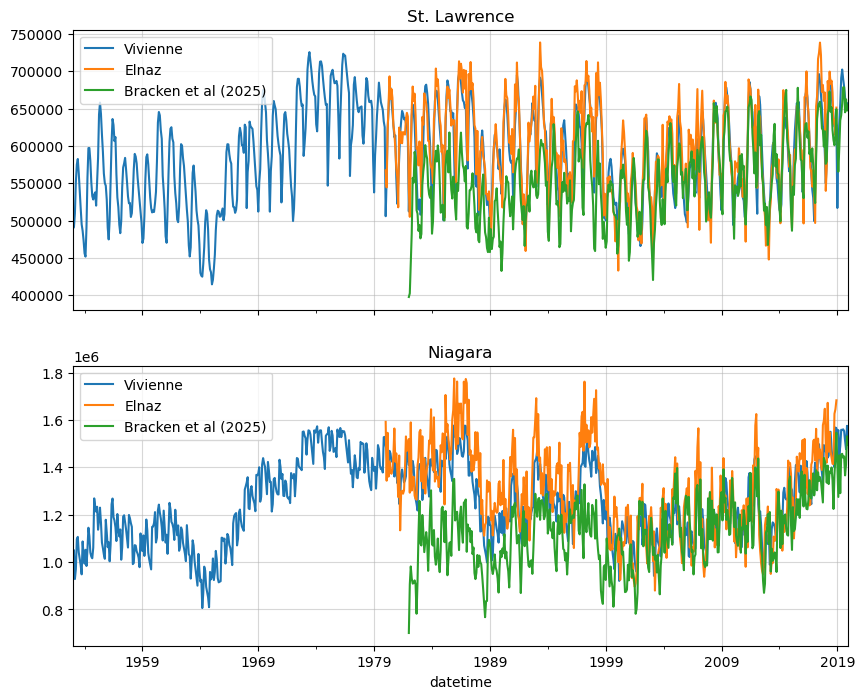

In [5]:
fig, axs = plt.subplots(2,1, figsize=(10,8), sharex=True)
# STL
ax = axs[0]
df_stl.set_index('datetime').resample('ME').sum()['nypaMosesSaundersEnergy'].plot(ax=ax, label='Vivienne')
df_elnaz_stl.resample('ME').sum()['HydroPower'].loc['1980':'2018'].plot(ax=ax, label='Elnaz')
df_gd_stl.set_index('datetime')['power_predicted_mwh'].plot(ax=ax, label='Bracken et al (2025)')
ax.legend()
ax.grid(alpha=0.5)
ax.set_title('St. Lawrence')

# Niagara
ax = axs[1]
df_niag.set_index('datetime').resample('ME').sum()['nypaNiagaraEnergy'].plot(ax=ax, label='Vivienne')
df_elnaz_niag.resample('ME').sum()['HydroPower'].loc['1980':'2018'].plot(ax=ax, label='Elnaz')
df_gd_niagara.set_index('datetime')['power_predicted_mwh'].plot(ax=ax, label='Bracken et al (2025)')
ax.legend()
ax.grid(alpha=0.5)
ax.set_title('Niagara')

plt.show()

In [6]:
# # Read scenarios
# df_scen = pd.read_csv('../../data/hydro/DU_factors_v3_300.csv', header=None)

In [7]:
# # Wide to long
# df_niag_long = (
#     pd.wide_to_long(df_niag.drop(columns=['nypaNiagaraEnergy', 'datetime']), 
#                     stubnames='nypaNiagaraEnergy.',
#                     i=['Year', 'Month', 'QM'],
#                     j='scenario')
#     .rename(columns={'nypaNiagaraEnergy.':'nypaNiagaraEnergy'})
#     .reset_index()
# )

# df_stl_long = (
#     pd.wide_to_long(df_stl.drop(columns=['nypaMosesSaundersEnergy', 'datetime']), 
#                     stubnames='nypaMosesSaundersEnergy.',
#                     i=['Year', 'Month', 'QM'],
#                     j='scenario')
#     .rename(columns={'nypaMosesSaundersEnergy.':'nypaMosesSaundersEnergy'})
#     .reset_index()
# )

In [8]:
# # Scenario to temperature delta mapping
# mapping = {df_scen.iloc[i][6]:df_scen.iloc[i][0] for i in df_scen.drop_duplicates(subset=6).index}

# df_stl_long['temperature_delta'] = df_stl_long['scenario'].apply(lambda x: mapping[int(x)] if x in mapping.keys() else np.nan)
# df_niag_long['temperature_delta'] = df_niag_long['scenario'].apply(lambda x: mapping[int(x)] if x in mapping.keys() else np.nan)

In [9]:
# Bracken CC scenarios
df_gd_cc = pd.concat([
    pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/godeeep-hydro/godeeep-hydro-rcp45cooler-monthly.csv'),
    pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/godeeep-hydro/godeeep-hydro-rcp45hotter-monthly.csv'),
    pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/godeeep-hydro/godeeep-hydro-rcp85cooler-monthly.csv'),
    pd.read_csv('/home/shared/vs498_0001/david-acorn-julia-repo/data/hydro/godeeep-hydro/godeeep-hydro-rcp85hotter-monthly.csv')
])
df_gd_cc['datetime'] = pd.to_datetime(df_gd_cc['datetime'])

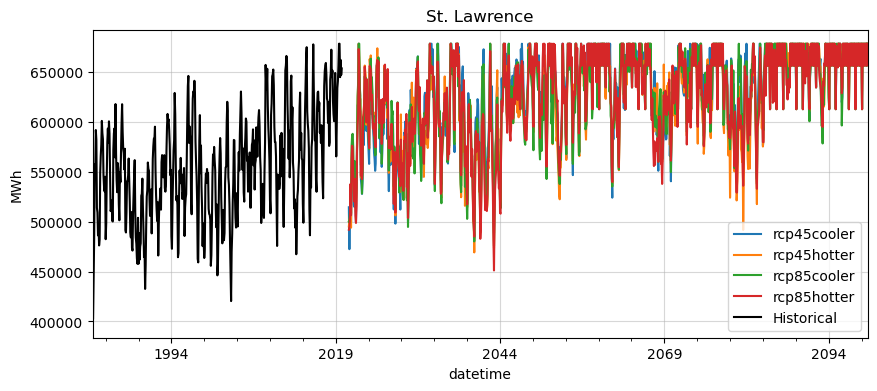

In [10]:
fig, ax = plt.subplots(figsize=(10,4))
df_gd_cc[df_gd_cc['plant'] == 'Robert Moses - St. Lawrence'].set_index('datetime').groupby('scenario')['power_predicted_mwh'].plot(ax=ax)
df_gd_stl.set_index('datetime')['power_predicted_mwh'].plot(ax=ax, label='Historical', color='black')
ax.grid(alpha=0.5)
ax.legend()
ax.set_title('St. Lawrence')
ax.set_ylabel('MWh')
plt.show()

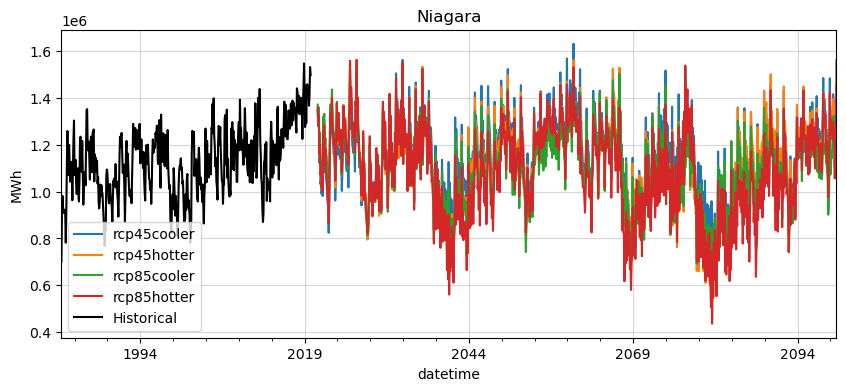

In [11]:
fig, ax = plt.subplots(figsize=(10,4))
df_gd_cc[df_gd_cc['plant'] == 'Robert Moses Niagara'].set_index('datetime').groupby('scenario')['power_predicted_mwh'].plot(ax=ax)
df_gd_niagara.set_index('datetime')['power_predicted_mwh'].plot(ax=ax, label='Historical', color='black')
ax.grid(alpha=0.5)
ax.legend()
ax.set_title('Niagara')
ax.set_ylabel('MWh')
plt.show()

In [12]:
# TGW warming deltas
df_deltas_rcp85hotter = pd.read_csv('/home/fs01/dcl257/data/TGW_WarmingDeltas/CONUS_Monthly_Delta_rcp85hotter.csv')
df_deltas_rcp45cooler = pd.read_csv('/home/fs01/dcl257/data/TGW_WarmingDeltas/CONUS_Monthly_Delta_rcp45cooler.csv')

PermissionError: [Errno 13] Permission denied: '/home/fs01/dcl257/data/TGW_WarmingDeltas/CONUS_Monthly_Delta_rcp85hotter.csv'

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,4))
df_deltas_rcp85hotter.set_index('Year').plot(ax=axs[0])
axs[0].set_title('RCP8.5 hotter')
df_deltas_rcp45cooler.set_index('Year').plot(ax=axs[1])
axs[1].set_title('RCP4.5 cooler')
plt.show()